In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import glob
import pingouin as pg
from scipy.stats import ttest_ind 


# Important functions

In [3]:
def analyze_groups_anova(df, score_col, group_col):
    # Extract data for each group
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == group][score_col].dropna() for group in groups]
    
    # Combine all groups into one dataset
    all_data = pd.concat(group_data)
    grand_mean = all_data.mean()

    # Calculate Sum of Squares Between (SS_between)
    SS_between = sum(len(group) * (group.mean() - grand_mean)**2 for group in group_data)

    # Calculate Sum of Squares Within (SS_within)
    SS_within = sum(sum((group - group.mean())**2) for group in group_data)

    # Calculate Total Sum of Squares (SS_total)
    SS_total = SS_between + SS_within

    # Calculate Eta Squared (η²)
    eta_squared = SS_between / SS_total

    # Perform one-way ANOVA
    stat, p = f_oneway(*group_data)

    # Print results
    print("SS stands for Sum of Squares")
    print(f"SS_between: {SS_between:.4f}")
    print(f"SS_within: {SS_within:.4f}")
    print(f"SS_total: {SS_total:.4f}")
    print(f"Effect Size (Eta Squared, η²): {eta_squared:.4f}")
    print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("There is a significant difference between the groups.")
    else:
        print("No significant difference between the groups.")

    # Plot the scores for each group
    plt.figure(figsize=(8, 6))
    boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)
    plt.title(f"{score_col} by {group_col}")

    # Assign different colors to each group
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    plt.ylabel(score_col)
    plt.xlabel(group_col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Return results as a dictionary
    return {
        "SS_between": SS_between,
        "SS_within": SS_within,
        "SS_total": SS_total,
        "eta_squared": eta_squared,
        "anova_stat": stat,
        "anova_p_value": p
    }

In [4]:
def analyze_kruskal_test(df, score_col, group_col):
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == group][score_col].dropna() for group in groups]
    stat, p = kruskal(*group_data)
    print(f"Kruskal-Wallis test statistic = {stat:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("There is a significant difference between the groups.")
    else:
        print("No significant difference between the groups.")
    plt.figure(figsize=(8, 6))
    boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)
    plt.title(f"{score_col} by {group_col} (Kruskal-Wallis Test)")
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    plt.ylabel(score_col)
    plt.xlabel(group_col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Return results as a dictionary
    return {
        "kruskal_stat": stat,
        "kruskal_p_value": p
    }

In [5]:
def calculate_omega(data):
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(data)
    loadings = fa.loadings_[:, 0]
    uniquenesses = fa.get_uniquenesses()
    numerator = np.sum(loadings)**2
    denominator = numerator + np.sum(uniquenesses)
    return numerator / denominator

In [6]:
# score meaning is (Source: Steiner, 2003, p102)
def interpret_omega(score):
    if score > 0.9:
        return "Excellent"
    elif 0.7 <= score <= 0.9:
        return "Good"
    elif 0.6 <= score < 0.7:
        return "Acceptable"
    elif 0.5 <= score < 0.6:
        return "Poor"
    else:
        return "Unacceptable"

In [7]:
def testing_for_assumptions_by_group(df, score_col="IEQ Score", group_col="Group"):
    print(f"# Testing assumptions for {score_col} #\n")

    groups = df[group_col].unique()
    group_data = {g: df[df[group_col] == g][score_col].dropna() for g in groups}

    # 1. Shapiro–Wilk Test for Normality
    print("## Shapiro–Wilk Test for Normality ##")
    normality = {}
    for group, data in group_data.items():
        print(f"Group {group}:")
        if len(data) < 3:
            print(f"  ⚠️ Not enough data (n={len(data)}) to test normality.\n")
            normality[group] = False
            continue
        stat, p = shapiro(data)
        normal = p > 0.05
        normality[group] = normal
        if normal:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Data appears normal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Data not normal\n")

    print("## Levene’s Test for Equal Variances ##")
    data_lists = [d for d in group_data.values() if len(d) >= 2]
    if len(data_lists) >= 2:
        stat, p = levene(*data_lists)
        equal_var = p > 0.05
        if equal_var:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Variances are equal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Variances are not equal\n")
    else:
        equal_var = False
        print("  ⚠️ Not enough groups with sufficient data to test variance\n")

    print(f"# Final Group Comparison Test for {score_col} #")
    normal_all = all(normality.values())
    sufficient_groups = len([group_data[g] for g in groups if len(group_data[g]) >= 2]) > 2
    if normal_all and equal_var:
        print("✅ All assumptions met. Running ANOVA:")
        if(sufficient_groups):
            stat, p = f_oneway(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ ANOVA Stat = {stat:.4f}, p = {p:.4f}")
        return 1
    else:
        print("❌ Assumptions not met. Using non-parametric Kruskal–Wallis:")
        if(sufficient_groups):
            stat, p = kruskal(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ Kruskal–Wallis Stat = {stat:.4f}, p = {p:.4f}")
        return 0


# Pre-Questionnaire Data Processingprocessing

Load the xlsx file

In [8]:
pre_path = glob.glob("Qustionare_data\\Pre\\*.xlsx")[0]
print(pre_path)
df = pd.read_excel(pre_path, sheet_name=0)
columns_to_plot = [
    "What is your age?",
    "Do you use glasses?",
    "VR",
    "Bartending",
    "Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?"
]
df 

Qustionare_data\Pre\MED 802 Test survey (Part 1)(1-31).xlsx


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Do you consent?,What is your age?,Do you use glasses?,VR,Bartending,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Your test Number (Get your test conductor to fill this out)
0,4,2025-05-05 11:33:00,2025-05-05 11:33:12,anonymous,NaN,NaN,Yes,25-34,No,A lot,NaN,Minor heart condition;,1
1,5,2025-05-05 11:55:57,2025-05-05 12:05:58,anonymous,NaN,NaN,Yes,25-34,Yes,Medium,Quite a bit,Caffeine;,2
2,6,2025-05-05 14:01:59,2025-05-05 14:04:33,anonymous,NaN,NaN,Yes,25-34,No,Medium,Medium,Matcha;,3
3,7,2025-05-05 14:35:11,2025-05-05 14:36:29,anonymous,NaN,NaN,Yes,18-24,No,A little,NaN,None;,4
4,8,2025-05-05 14:56:05,2025-05-05 14:57:19,anonymous,NaN,NaN,Yes,25-34,No,Quite a bit,A little,Caffeine;,5
5,9,2025-05-06 09:06:37,2025-05-06 09:35:53,anonymous,NaN,NaN,Yes,18-24,I'm using lenses right now,A little,NaN,None;,6
6,10,2025-05-06 09:37:24,2025-05-06 10:03:18,anonymous,NaN,NaN,Yes,18-24,No,A little,Medium,Caffeine;,7
7,11,2025-05-06 10:03:21,2025-05-06 10:31:30,anonymous,NaN,NaN,Yes,18-24,Yes,A little,NaN,Caffeine;,8
8,12,2025-05-06 10:32:24,2025-05-06 11:02:29,anonymous,NaN,NaN,Yes,18-24,Yes,A little,NaN,None;,9
9,13,2025-05-06 12:34:07,2025-05-06 12:34:12,anonymous,NaN,NaN,Yes,18-24,Yes,NaN,Medium,Caffeine;,10


In [9]:
# Initialize an empty DataFrame to store the results
answer_counts_df = pd.DataFrame()

for column in columns_to_plot:
    # Extract data from each column, count unique answers, and add to the new DataFrame
    answer_counts = df[column].value_counts().reset_index()
    answer_counts.columns = [column, "Count"]
    answer_counts_df = pd.concat([answer_counts_df, answer_counts], axis=1)

# Calculate z-scores for each column with numerical data
z_scores = answer_counts_df.select_dtypes(include=['float64', 'int64']).apply(stats.zscore)

answer_counts_df['Outlier'] = (z_scores.abs() > 3).any(axis=1)

answer_counts_df

,What is your age?,Count,Do you use glasses?,Count,VR,Count,Bartending,Count,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Count,Outlier
0,18-24,17.0,No,20.0,A little,8.0,Medium,8.0,None;,19,False
1,25-34,14.0,Yes,9.0,Quite a bit,8.0,Quite a bit,5.0,Caffeine;,7,False
2,NaN,NaN,I'm using lenses right now,2.0,Medium,7.0,A little,5.0,Minor heart condition;,1,False
3,NaN,NaN,NaN,NaN,A lot,4.0,NaN,NaN,Matcha;,1,False
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medicine ;,1,False
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A wittle bit sick;,1,False
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"if HRT counts, then that;",1,False


C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\750008034.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="VR", palette="viridis")


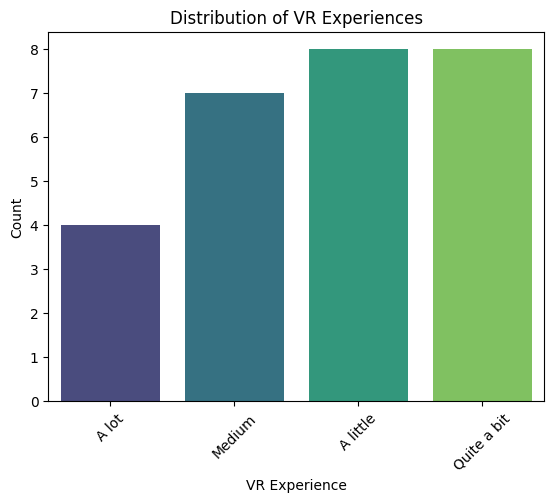

In [10]:
sns.countplot(data=df, x="VR", palette="viridis")
plt.title("Distribution of VR Experiences")
plt.xlabel("VR Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\3884211921.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Bartending", palette="viridis")


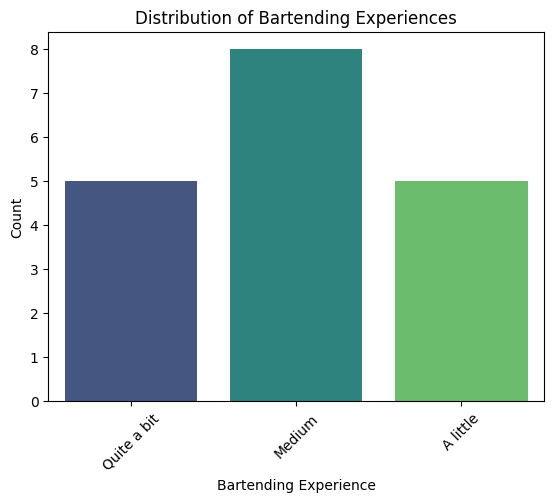

In [11]:
sns.countplot(data=df, x="Bartending", palette="viridis")
plt.title("Distribution of Bartending Experiences")
plt.xlabel("Bartending Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Post-Questionaire Data Processing

In [12]:
post_path = glob.glob("Qustionare_data\\Post\\*.xlsx")[0]
print(post_path)
df_post = pd.read_excel(post_path, sheet_name=0)
df_post 

Qustionare_data\Post\MED 802 Test survey (Part 2)(1-31).xlsx


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Participant Number (Test conductor fills out),What group is this? (Test conductor fills out)\n,"To what extent did the game hold your attention? ( 7= A lot, 1 = Not at all )","To what extent did you feel you were focused on the game? ( 7= A lot, 1 = Not at all )",...,"How much would you say you enjoyed playing the game? ( 7= A lot, 1 = Not at all)","When it ended, were you disappointed that the game was over? ( 7= Very much so, 1 = Not at all)","Would you like to play the game again? ( 7 = Definitely yes, 1 = Definitely no)",How immersed did you feel?,"How mentally demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How physically demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How hurried or rushed was the pace of the task? (1 being ""Very low"" and 20 being ""Very high"")","How successful were you in accomplishing what you were asked to do? (1 being ""Very low"" and 20 being ""Very high"")","How hard did you have to work to accomplish your level of performance? (1 being ""Very low"" and 20 being ""Very high"")","How insecure, discouraged, irritated, stressed, and annoyed were you? (1 being ""Very low"" and 20 being ""Very high"")"
0,6,2025-05-05 10:03:43,2025-05-05 11:54:50,anonymous,NaN,NaN,1,Group C,6,7,...,6,5,7,7,10,3,6,13,13,8
1,7,2025-05-05 13:17:55,2025-05-05 13:35:54,anonymous,NaN,NaN,2,Group C,5,7,...,4,5,3,6,14,6,5,4,16,9
2,8,2025-05-05 14:01:48,2025-05-05 14:25:06,anonymous,NaN,NaN,3,Group B,5,7,...,4,7,7,10,14,6,1,1,21,5
3,9,2025-05-05 14:35:10,2025-05-05 14:55:15,anonymous,NaN,NaN,4,Group C,6,7,...,6,5,6,7,6,5,3,19,12,1
4,10,2025-05-05 15:16:02,2025-05-05 15:19:07,anonymous,NaN,NaN,5,Group C,7,5,...,6,7,7,9,17,19,18,2,18,11
5,11,2025-05-06 09:06:46,2025-05-06 09:57:10,anonymous,NaN,NaN,6,Group B,7,7,...,7,5,7,8,6,7,5,18,8,6
6,12,2025-05-06 10:25:40,2025-05-06 10:25:47,anonymous,NaN,NaN,7,Group A,7,7,...,7,6,7,7,13,7,15,3,17,10
7,13,2025-05-06 10:25:51,2025-05-06 10:56:46,anonymous,NaN,NaN,8,Group C,7,7,...,7,7,7,9,10,1,8,7,6,1
8,14,2025-05-06 10:56:52,2025-05-06 11:22:07,anonymous,NaN,NaN,9,Group B,6,7,...,6,7,6,8,5,2,1,3,4,14
9,15,2025-05-06 12:57:58,2025-05-06 12:58:03,anonymous,NaN,NaN,10,Group B,6,6,...,6,6,7,7,6,4,3,4,4,4


## Nasa-tlx

In [13]:
last_6_columns = df_post.iloc[:, -6:].copy()
last_6_columns.columns = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level"
]

last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)

TLX_allScore["Participant Number"] = df_post.iloc[:, 6]
TLX_allScore["Group"] = df_post.iloc[:, 7]
TLX_allScore["TLX Score"] = TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]].mean(axis=1)

omega_value = calculate_omega(TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]])

print(f"The reliability of the Nasa-TLX was {interpret_omega(omega_value)}, with a McDonald's Omega (TLX combined) = {omega_value:.3f}")

TLX_allScore


The reliability of the Nasa-TLX was Acceptable, with a McDonald's Omega (TLX combined) = 0.622


C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\3136339585.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\3136339585.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)


,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,Group,TLX Score
0,50,15,30,65,65,40,1,Group C,44.166667
1,70,30,25,20,80,45,2,Group C,45.000000
2,70,30,5,5,100,25,3,Group B,39.166667
3,30,25,15,95,60,5,4,Group C,38.333333
4,85,95,90,10,90,55,5,Group C,70.833333
5,30,35,25,90,40,30,6,Group B,41.666667
6,65,35,75,15,85,50,7,Group A,54.166667
7,50,5,40,35,30,5,8,Group C,27.500000
8,25,10,5,15,20,70,9,Group B,24.166667
9,30,20,15,20,20,20,10,Group B,20.833333


In [14]:
TLX_allScore.describe()

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,TLX Score
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,51.451613,39.193548,35.645161,54.354839,56.290323,30.806452,16.000000,44.623656
std,20.663718,24.224532,23.371704,26.323055,20.492590,20.457141,9.092121,11.962207
min,15.000000,5.000000,5.000000,5.000000,20.000000,5.000000,1.000000,20.833333
25%,32.500000,22.500000,20.000000,35.000000,40.000000,15.000000,8.500000,38.333333
50%,50.000000,35.000000,25.000000,65.000000,60.000000,25.000000,16.000000,44.166667
75%,67.500000,50.000000,47.500000,72.500000,70.000000,47.500000,23.500000,49.166667
max,85.000000,95.000000,90.000000,95.000000,100.000000,70.000000,31.000000,70.833333


### Testing for assumptions

In [15]:
testing_for_assumptions_by_group(TLX_allScore, score_col="TLX Score", group_col="Group")

# Testing assumptions for TLX Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9355, p = 0.4422 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8727, p = 0.1075 → Data appears normal

Group Group A:
  ✔️ Stat = 0.8874, p = 0.1875 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 1.1763, p = 0.3232 → Variances are equal

# Final Group Comparison Test for TLX Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.4453, p = 0.2527


1

In [16]:
testing_for_assumptions_by_group(TLX_allScore,score_col="Performance")

# Testing assumptions for Performance #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9230, p = 0.3118 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9573, p = 0.7548 → Data appears normal

Group Group A:
  ❌ Stat = 0.7582, p = 0.0068 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.4585, p = 0.6369 → Variances are equal

# Final Group Comparison Test for Performance #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 1.5470, p = 0.4614


0

### Creating the different groups

In [17]:
group_a_tlx = TLX_allScore[TLX_allScore["Group"] == "Group A"]["TLX Score"]
group_b_tlx = TLX_allScore[TLX_allScore["Group"] == "Group B"]["TLX Score"]
group_c_tlx = TLX_allScore[TLX_allScore["Group"] == "Group C"]["TLX Score"]

### Anova for TLX

C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\3431445066.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)


SS stands for Sum of Squares
SS_between: 401.6934
SS_within: 3891.1381
SS_total: 4292.8315
Effect Size (Eta Squared, η²): 0.0936
ANOVA Results: F-statistic = 1.4453, p-value = 0.2527
No significant difference between the groups.


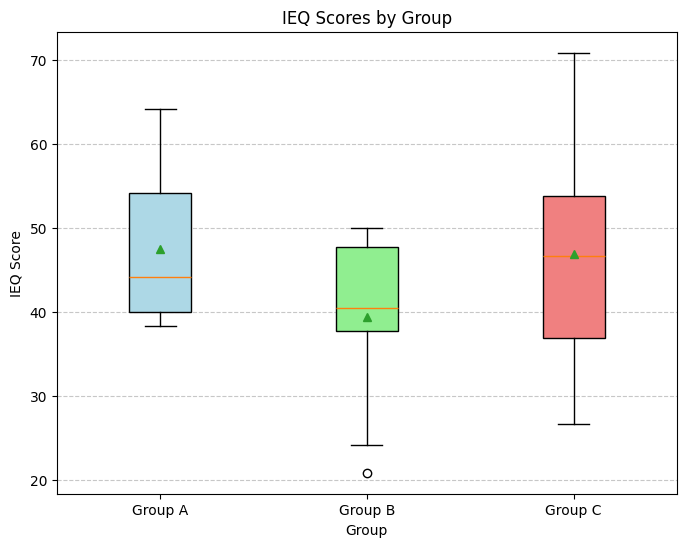

In [18]:
# Combine all groups into one dataset
all_data = pd.concat([group_a_tlx, group_b_tlx, group_c_tlx])
grand_mean = all_data.mean()

# Calculate Sum of Squares Between (SS_between)
n_a, n_b, n_c = len(group_a_tlx), len(group_b_tlx), len(group_c_tlx)
mean_a_tlx, mean_b_tlx, mean_c_tlx = group_a_tlx.mean(), group_b_tlx.mean(), group_c_tlx.mean()
SS_between_tlx = n_a * (mean_a_tlx - grand_mean)**2 + n_b * (mean_b_tlx - grand_mean)**2 + n_c * (mean_c_tlx - grand_mean)**2

# Calculate Sum of Squares Within (SS_within)
SS_within_tlx = sum((group_a_tlx - mean_a_tlx)**2) + sum((group_b_tlx - mean_b_tlx)**2) + sum((group_c_tlx - mean_c_tlx)**2)

# Calculate Total Sum of Squares (SS_total)
SS_total_tlx = SS_between_tlx + SS_within_tlx

# Calculate Eta Squared (η²)
eta_squared_tlx = SS_between_tlx / SS_total_tlx

# Print results
print("SS stands for Sum of Squares")
print(f"SS_between: {SS_between_tlx:.4f}")
print(f"SS_within: {SS_within_tlx:.4f}")
print(f"SS_total: {SS_total_tlx:.4f}")
print(f"Effect Size (Eta Squared, η²): {eta_squared_tlx:.4f}")

# Perform one-way ANOVA
stat, p = f_oneway(group_a_tlx, group_b_tlx, group_c_tlx)
print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
if p < 0.05:
    print("There is a significant difference between the groups.")
else:
    print("No significant difference between the groups.")

# Plot the scores for each group
plt.figure(figsize=(8, 6))
data = [group_a_tlx, group_b_tlx, group_c_tlx]
boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)
plt.title("IEQ Scores by Group")

# Assign different colors to each group
colors = ['lightblue', 'lightgreen', 'lightcoral']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)

plt.ylabel("IEQ Score")
plt.xlabel("Group")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Compaersing between groups for each individual messure

In [76]:
# Columns to test
columns_to_test = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level"]

# Initialize a list to store the results
results = []

for col in columns_to_test:
    print(f"\n### Testing for {col} ###")
    
    # Extract data for each group
    group_a = TLX_allScore[TLX_allScore["Group"] == "Group A"][col]
    group_b = TLX_allScore[TLX_allScore["Group"] == "Group B"][col]
    group_c = TLX_allScore[TLX_allScore["Group"] == "Group C"][col]
    
    # Check assumptions and decide the test
    test_type = testing_for_assumptions_by_group(TLX_allScore, score_col=col, group_col="Group")
    
    if test_type == 1:  # ANOVA
        print(f"Running ANOVA for {col}")
        stat, p = f_oneway(group_a, group_b, group_c)
        test_name = "ANOVA"
    elif test_type == 0:  # Kruskal-Wallis
        print(f"Running Kruskal-Wallis for {col}")
        stat, p = kruskal(group_a, group_b, group_c)
        test_name = "Kruskal-Wallis"
    else:
        print(f"Not enough data to test {col}.")
        results.append({"Column": col, "Test": "Not enough data", "p-value": None, "Significant": "No"})
        continue  # Skip to the next column if there's not enough data
    
    # Determine significance
    significant = "Yes" if p < 0.05 else "No"
    
    # Append the result to the list
    results.append({"Column": col, "Test": test_name, "p-value": p, "Significant": significant})
    
    # If p-value is less than 0.05, create a plot
    if p < 0.05:
        print(f"Significant result for {col} (p = {p:.4f}). Creating a plot...")
        
        # Combine data for plotting
        data = [group_a, group_b, group_c]
        labels = ["Group A", "Group B", "Group C"]
        
        # Create a boxplot
        plt.figure(figsize=(8, 6))
        boxplot = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True)
        
        # Assign colors to each group
        colors = ['lightblue', 'lightgreen', 'lightcoral']
        for patch, color in zip(boxplot['boxes'], colors):
            patch.set_facecolor(color)
        
        # Add plot title and labels
        plt.title(f"{col} by Group")
        plt.ylabel(col)
        plt.xlabel("Group")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Show the plot
        plt.show()

# Create a summary DataFrame
summary_df_tlx = pd.DataFrame(results)

# Display the summary DataFrame
print("\n### Summary of Findings ###")
print(summary_df_tlx )


### Testing for Mental Demand ###
# Testing assumptions for Mental Demand #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9292, p = 0.3714 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8619, p = 0.0803 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9660, p = 0.8585 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.4555, p = 0.6388 → Variances are equal

# Final Group Comparison Test for Mental Demand #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.5583, p = 0.2282
Running ANOVA for Mental Demand

### Testing for Physical Demand ###
# Testing assumptions for Physical Demand #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9074, p = 0.1975 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9079, p = 0.2671 → Data appears normal

Group Group A:
  ✔️ Stat = 0.8630, p = 0.1034 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.1209, p = 0.8866 → Variances are equal

# Fin

## IEQ

In [20]:
questions_df = df_post.iloc[:, 8:39].copy()
questions_df = questions_df.apply(pd.to_numeric, errors='coerce')

questions_to_reverse_indices = [5, 7, 9, 17, 19]
for index in questions_to_reverse_indices:
    column_name = questions_df.columns[index]
    questions_df[column_name] = 8 - questions_df[column_name]

IEQ_scores_list = questions_df.sum(axis=1, skipna=True)
IEQ_scores = pd.DataFrame({
    "IEQ Score": IEQ_scores_list,
    "Participant Number": df_post.iloc[:, 6].values,
    "Group": df_post.iloc[:, 7].values,
    "Single Question Measure of Immersion": df_post.iloc[:, 39].values
})

omega_ieq = calculate_omega(questions_df)
print(f"The reliability of the IEQ was {interpret_omega(omega_ieq)}, with a McDonald's Omega (TLX combined) = {omega_ieq:.3f}")
IEQ_scores

The reliability of the IEQ was Good, with a McDonald's Omega (TLX combined) = 0.796


,IEQ Score,Participant Number,Group,Single Question Measure of Immersion
0,173,1,Group C,7
1,137,2,Group C,6
2,161,3,Group B,10
3,163,4,Group C,7
4,172,5,Group C,9
5,161,6,Group B,8
6,171,7,Group A,7
7,159,8,Group C,9
8,166,9,Group B,8
9,167,10,Group B,7


In [21]:
IEQ_scores.describe()

,IEQ Score,Participant Number,Single Question Measure of Immersion
count,31.000000,31.000000,31.000000
mean,162.677419,16.000000,7.548387
std,13.131101,9.092121,1.286823
min,137.000000,1.000000,5.000000
25%,156.000000,8.500000,7.000000
50%,161.000000,16.000000,7.000000
75%,173.500000,23.500000,8.000000
max,184.000000,31.000000,10.000000


### Testing for assumption before cleaning IEQ

In [22]:
testing_for_assumptions_by_group(IEQ_scores, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9042, p = 0.1798 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9320, p = 0.4681 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9342, p = 0.5225 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.1642, p = 0.8494 → Variances are equal

# Final Group Comparison Test for IEQ Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.0383, p = 0.3673


1

In [23]:
testing_for_assumptions_by_group(IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9151, p = 0.2482 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9337, p = 0.4851 → Data appears normal

Group Group A:
  ❌ Stat = 0.8098, p = 0.0264 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.7192, p = 0.4959 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 2.8057, p = 0.2459


0

### Describing different groups

### Describing the different groups

In [24]:
# Extract data for each group
group_a_ieq = IEQ_scores[IEQ_scores["Group"] == "Group A"]["IEQ Score"]
group_b_ieq = IEQ_scores[IEQ_scores["Group"] == "Group B"]["IEQ Score"]
group_c_ieq = IEQ_scores[IEQ_scores["Group"] == "Group C"]["IEQ Score"]

print("#Low fi group: ")
print(group_a_ieq.describe())

#Low fi group: 
count      9.000000
mean     160.555556
std       12.943252
min      144.000000
25%      155.000000
50%      157.000000
75%      171.000000
max      181.000000
Name: IEQ Score, dtype: float64


In [25]:
print("#Low mid group: ")
print(group_b_ieq.describe())

#Low mid group: 
count     10.000000
mean     159.500000
std       11.768602
min      137.000000
25%      155.250000
50%      161.000000
75%      166.750000
max      174.000000
Name: IEQ Score, dtype: float64


In [26]:
print("#Low hi group: ")
print(group_c_ieq.describe())

#Low hi group: 
count     12.000000
mean     166.916667
std       14.234774
min      137.000000
25%      159.000000
50%      172.500000
75%      178.000000
max      184.000000
Name: IEQ Score, dtype: float64


### IEQ anova test

SS stands for Sum of Squares
SS_between: 357.1353
SS_within: 4815.6389
SS_total: 5172.7742
Effect Size (Eta Squared, η²): 0.0690
ANOVA Results: F-statistic = 1.0383, p-value = 0.3673
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\1182566836.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


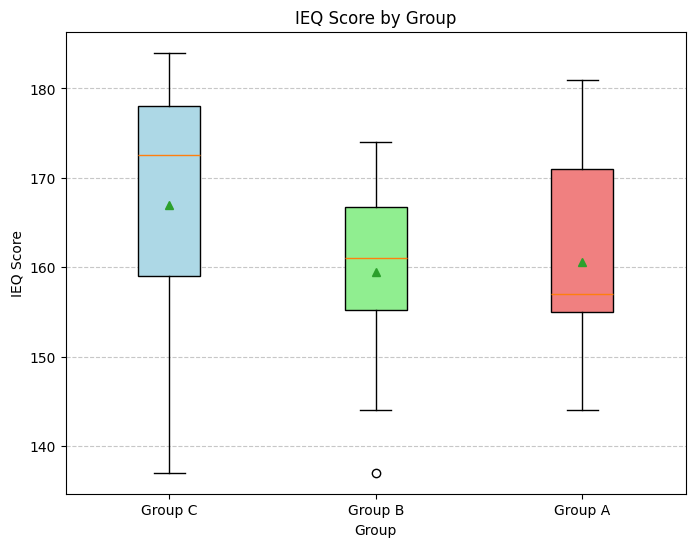

{'SS_between': 357.13530465949776, 'SS_within': 4815.638888888889, 'SS_total': 5172.774193548386, 'eta_squared': 0.06904134827785946, 'anova_stat': 1.0382618756504391, 'anova_p_value': 0.36730386029305573}


In [27]:
results_IEQ = analyze_groups_anova(df=IEQ_scores, score_col="IEQ Score", group_col="Group")
print(results_IEQ)

### Other Comparsing of IEQ then normale anova

In [28]:
print("Welch's ANOVA Results")
pg.welch_anova(dv='IEQ Score', between='Group', data=IEQ_scores) 

Welch's ANOVA Results


,Source,ddof1,ddof2,F,p-unc,np2
0,Group,2,18.216817,0.959411,0.401651,0.069041


In [29]:
# Group A vs Group C
stat_ac, p_ac = ttest_ind(group_c_ieq, group_b_ieq, equal_var=True)  # Use equal_var=True if variances are equal
print(f"Group A vs Group C: t-statistic = {stat_ac:.4f}, one-tailed p-value = {p_ac:.4f}")
# Group A vs Group B
stat_bc, p_bc = ttest_ind(group_c_ieq, group_b_ieq, equal_var=True)
print(f"Group B vs Group C: t-statistic = {stat_bc:.4f}, one-tailed p-value = {p_bc:.4f}")

Group A vs Group C: t-statistic = 1.3140, one-tailed p-value = 0.2037
Group B vs Group C: t-statistic = 1.3140, one-tailed p-value = 0.2037


### Kruskal test on Single Question mesure of immersion between groups

Kruskal-Wallis test statistic = 2.8057, p-value = 0.2459
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\23711797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


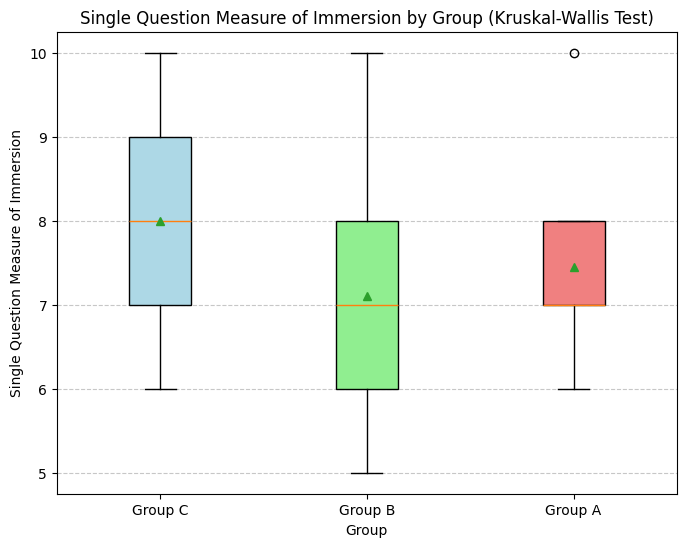

{'kruskal_stat': 2.8057347670250845, 'kruskal_p_value': 0.2458908886510533}


In [30]:
results = analyze_kruskal_test(df=IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")
print(results)

### cleaning IEQ with single question immersion

In [31]:
threshold = 31 
singleQuestionScalingFactor = 21.7 # (217 - 31)/10

# Calculate the absolute difference between the Single Question score and the IEQ Score
IEQ_scores["Difference"] = abs(IEQ_scores["Single Question Measure of Immersion"] * 21.7 - IEQ_scores["IEQ Score"])

# Identify rows where the difference exceeds the threshold
outliers_df = IEQ_scores[IEQ_scores["Difference"] > threshold]

# Print the outliers
print("Outliers based on the difference between Single Question and IEQ Score:")
print(outliers_df)

# Optionally, drop the outliers from the original DataFrame
filtered_df = IEQ_scores[IEQ_scores["Difference"] <= threshold]
print(filtered_df.describe())
filtered_df

Outliers based on the difference between Single Question and IEQ Score:
    IEQ Score  Participant Number    Group  \
2         161                   3  Group B   
7         159                   8  Group C   
10        181                  11  Group A   
28        178                  29  Group C   

    Single Question Measure of Immersion  Difference  
2                                     10        56.0  
7                                      9        36.3  
10                                    10        36.0  
28                                    10        39.0  
        IEQ Score  Participant Number  Single Question Measure of Immersion  \
count   27.000000           27.000000                             27.000000   
mean   161.629630           16.481481                              7.222222   
std     13.237906            8.872474                              1.012739   
min    137.000000            1.000000                              5.000000   
25%    154.500000          

,IEQ Score,Participant Number,Group,Single Question Measure of Immersion,Difference
0,173,1,Group C,7,21.1
1,137,2,Group C,6,6.8
3,163,4,Group C,7,11.1
4,172,5,Group C,9,23.3
5,161,6,Group B,8,12.6
6,171,7,Group A,7,19.1
8,166,9,Group B,8,7.6
9,167,10,Group B,7,15.1
11,144,12,Group B,6,13.8
12,144,13,Group A,7,7.9


### Testing for Assuptions by groups 

In [32]:
testing_for_assumptions_by_group(filtered_df, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9034, p = 0.2388 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9349, p = 0.5290 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9237, p = 0.4603 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.2402, p = 0.7883 → Variances are equal

# Final Group Comparison Test for IEQ Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.1545, p = 0.3321


1

In [33]:
testing_for_assumptions_by_group(filtered_df, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.8737, p = 0.1105 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8838, p = 0.1719 → Data appears normal

Group Group A:
  ❌ Stat = 0.8104, p = 0.0370 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 2.5483, p = 0.0992 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 3.1803, p = 0.2039


0

### Anova on IEQ score 

SS stands for Sum of Squares
SS_between: 399.8963
SS_within: 4156.4000
SS_total: 4556.2963
Effect Size (Eta Squared, η²): 0.0878
ANOVA Results: F-statistic = 1.1545, p-value = 0.3321
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\1182566836.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


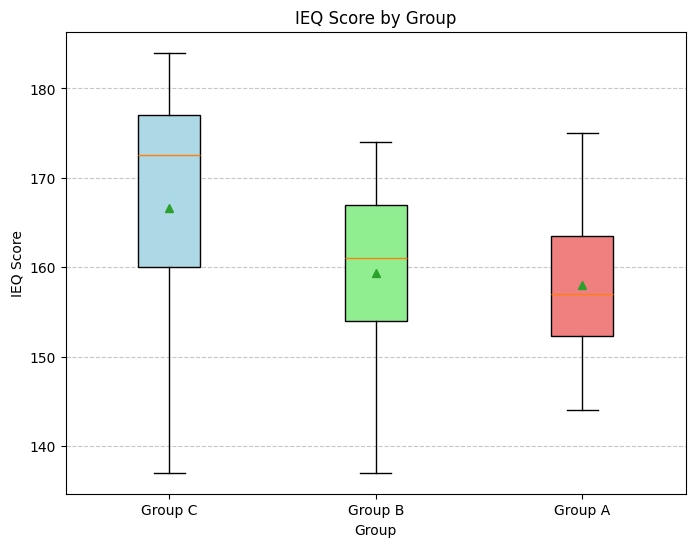

{'SS_between': 399.89629629629536, 'SS_within': 4156.4, 'SS_total': 4556.296296296295, 'eta_squared': 0.08776784262721492, 'anova_stat': 1.154546135009998, 'anova_p_value': 0.33209667810166993}


In [34]:
results_filterd_IEQ = analyze_groups_anova(df=filtered_df, score_col="IEQ Score", group_col="Group")
print(results_filterd_IEQ)

### Kruskal test on single question measure of immersion

Kruskal-Wallis test statistic = 3.1803, p-value = 0.2039
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_14408\23711797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


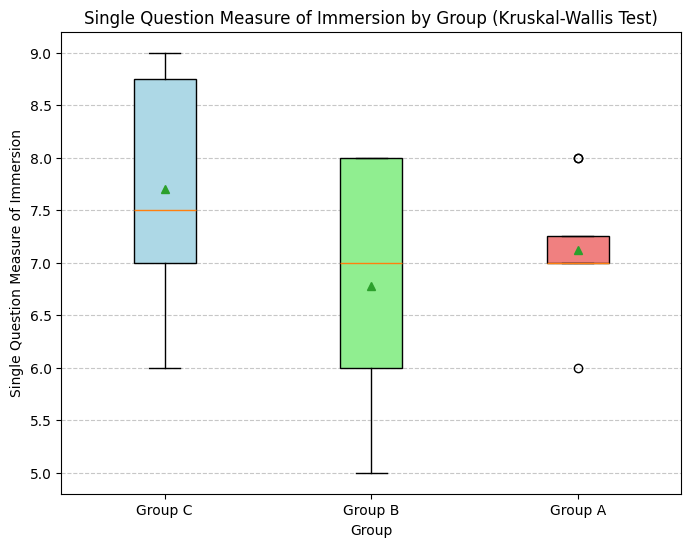

{'kruskal_stat': 3.180301672640381, 'kruskal_p_value': 0.20389485466504675}


In [35]:
results = analyze_kruskal_test(df=filtered_df, score_col="Single Question Measure of Immersion", group_col="Group")
print(results)

## comparing between IEQ and TLX

In [36]:
# Merge the two DataFrames on the "Participant Number" column
merged_df = pd.merge(TLX_allScore, IEQ_scores, on="Participant Number", suffixes=("_TLX", "_IEQ"))
merged_df

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,Group_TLX,TLX Score,IEQ Score,Group_IEQ,Single Question Measure of Immersion,Difference
0,50,15,30,65,65,40,1,Group C,44.166667,173,Group C,7,21.1
1,70,30,25,20,80,45,2,Group C,45.000000,137,Group C,6,6.8
2,70,30,5,5,100,25,3,Group B,39.166667,161,Group B,10,56.0
3,30,25,15,95,60,5,4,Group C,38.333333,163,Group C,7,11.1
4,85,95,90,10,90,55,5,Group C,70.833333,172,Group C,9,23.3
5,30,35,25,90,40,30,6,Group B,41.666667,161,Group B,8,12.6
6,65,35,75,15,85,50,7,Group A,54.166667,171,Group A,7,19.1
7,50,5,40,35,30,5,8,Group C,27.500000,159,Group C,9,36.3
8,25,10,5,15,20,70,9,Group B,24.166667,166,Group B,8,7.6
9,30,20,15,20,20,20,10,Group B,20.833333,167,Group B,7,15.1


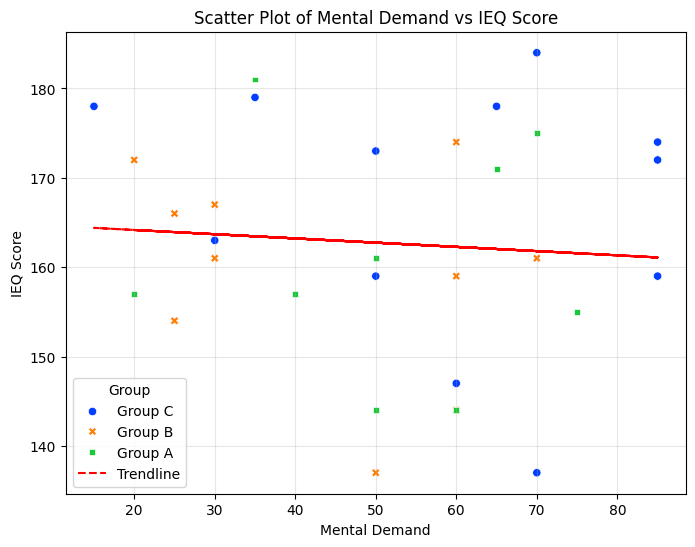

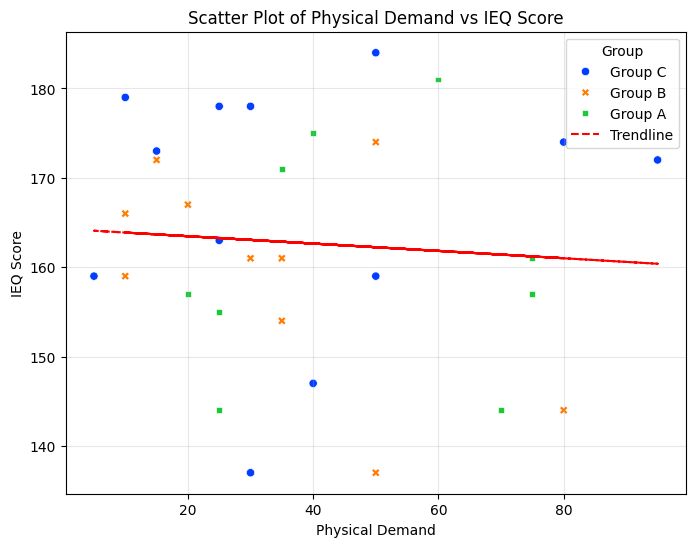

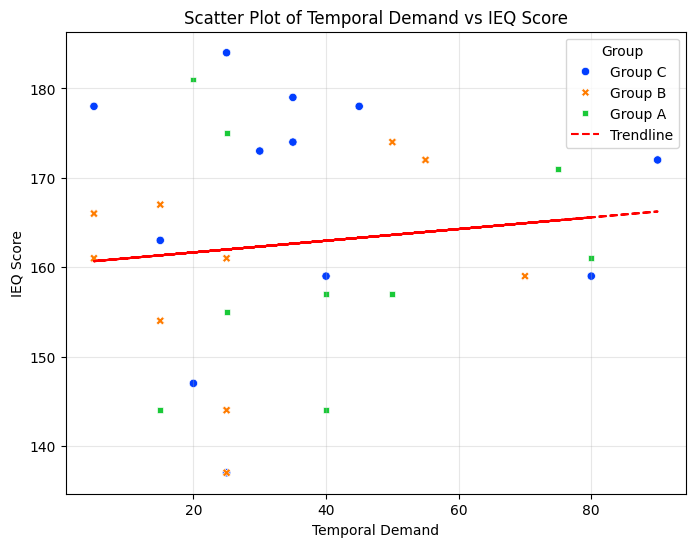

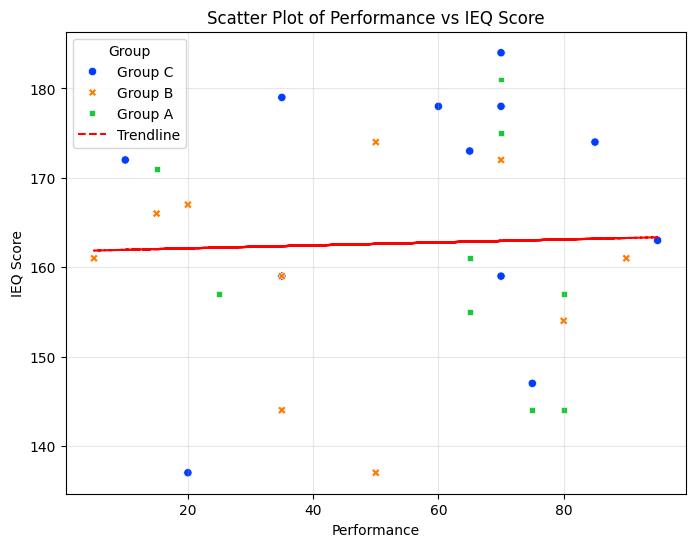

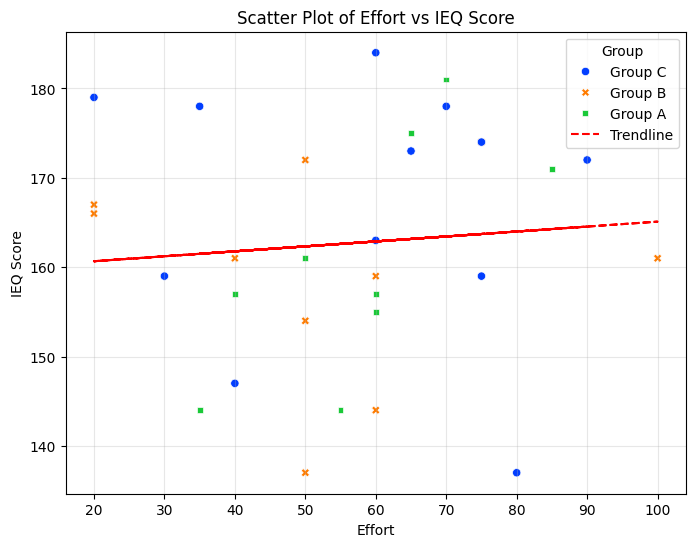

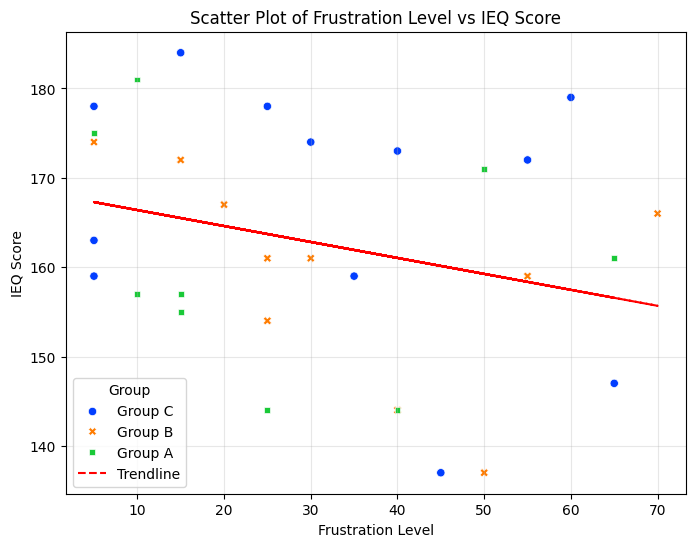

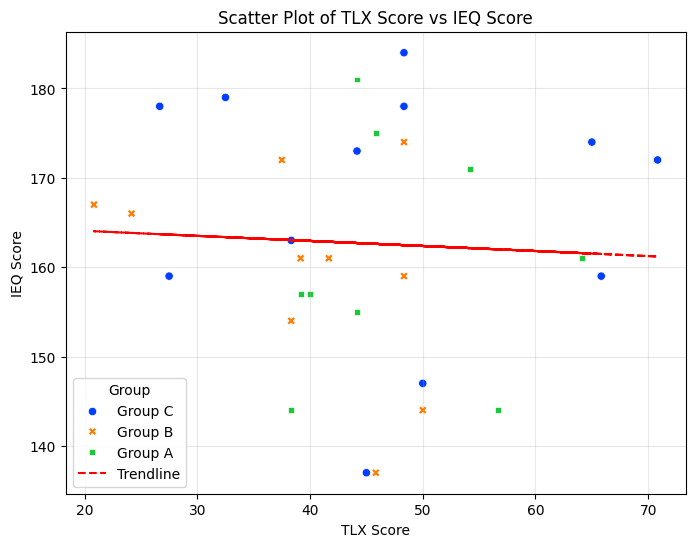

In [ ]:
# List of columns to compare with IEQ Score
columns_to_compare = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level", "TLX Score"]

for col in columns_to_compare:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=merged_df[col],
        y=merged_df["IEQ Score"],
        hue=merged_df["Group_IEQ"],
        palette="bright",
        style=merged_df["Group_IEQ"]
    )
    
    # Add a trendline
    z = np.polyfit(merged_df[col], merged_df["IEQ Score"], 1)
    p = np.poly1d(z)
    plt.plot(merged_df[col], p(merged_df[col]), color="red", linestyle="--", label="Trendline")
    
    # Add labels, title, and legend
    plt.xlabel(col)
    plt.ylabel("IEQ Score")
    plt.title(f"Scatter Plot of {col} vs IEQ Score")
    plt.legend(title="Group")
    plt.grid(alpha=0.3)
    plt.show()

# Test subjects general infomation

In [38]:
vr_experience_df = merged_df[["Participant Number", "Group_IEQ"]].copy()
vr_experience_df["VR Experience"] = df.iloc[:, 9].values
vr_experience_df["Bartending Experience"] = df.iloc[:, 10].values
vr_experience_df["Affect your heart rate?"]= df.iloc[:, 11].values
vr_experience_df.rename(columns={
    "Group_IEQ": "Group",
}, inplace=True)

vr_experience_df

# None = 1 , A little = 2, Medium = 3, Quite a bit = 4, A lot = 5

,Participant Number,Group,VR Experience,Bartending Experience,Affect your heart rate?
0,1,Group C,A lot,NaN,Minor heart condition;
1,2,Group C,Medium,Quite a bit,Caffeine;
2,3,Group B,Medium,Medium,Matcha;
3,4,Group C,A little,NaN,None;
4,5,Group C,Quite a bit,A little,Caffeine;
5,6,Group B,A little,NaN,None;
6,7,Group A,A little,Medium,Caffeine;
7,8,Group C,A little,NaN,Caffeine;
8,9,Group B,A little,NaN,None;
9,10,Group B,NaN,Medium,Caffeine;


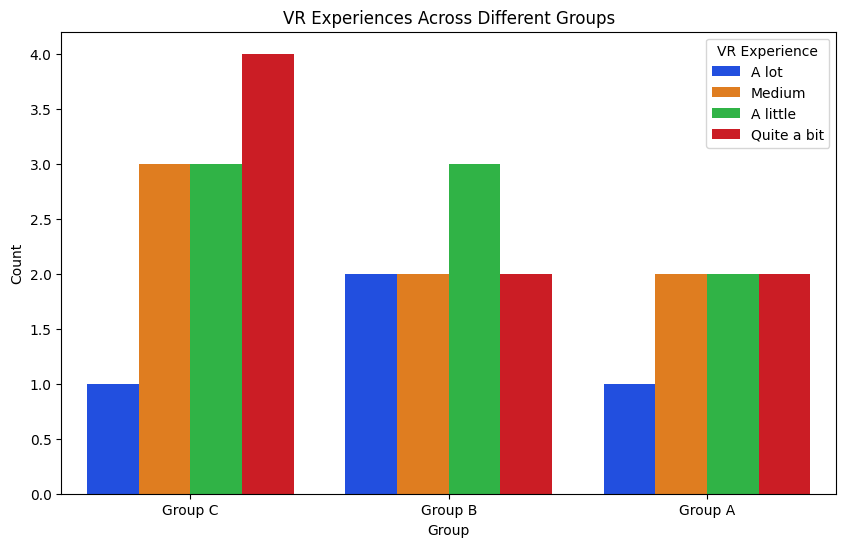

In [39]:
# Create a count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="VR Experience", palette="bright")
plt.title("VR Experiences Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="VR Experience")
plt.show()

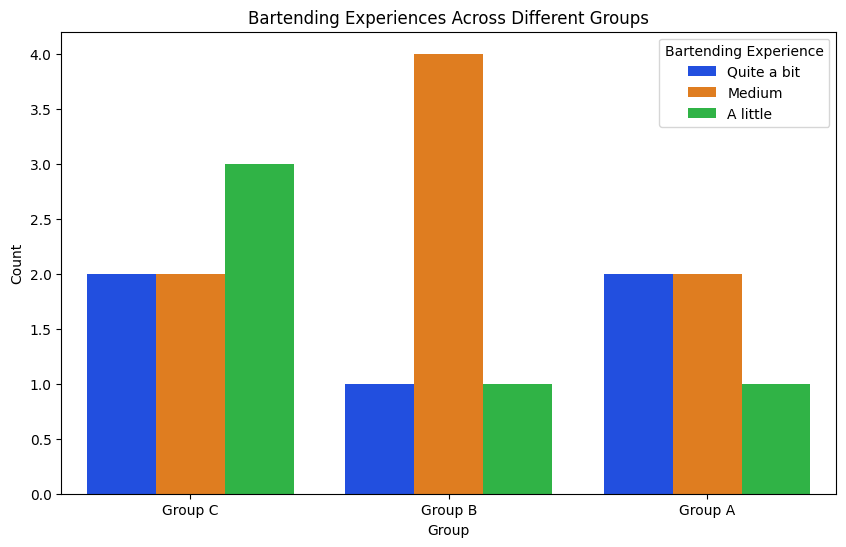

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="Bartending Experience", palette="bright")
plt.title("Bartending Experiences Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="Bartending Experience")
plt.show()

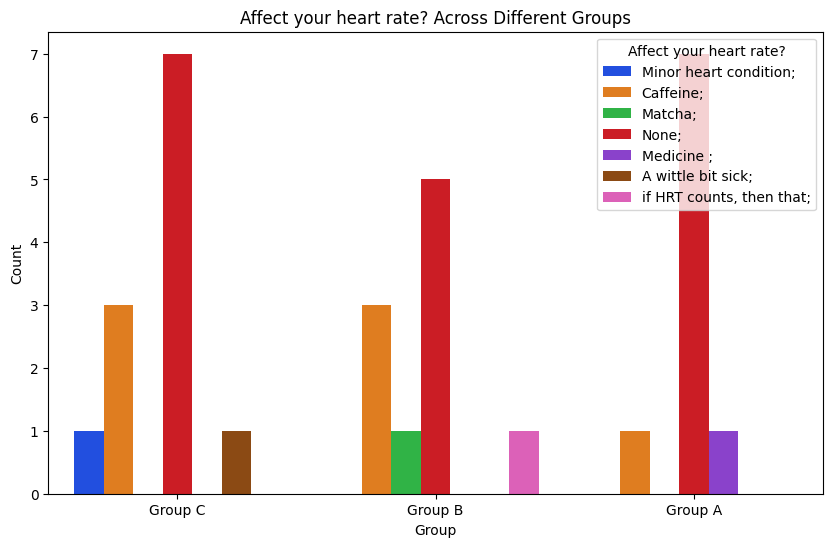

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="Affect your heart rate?", palette="bright")
plt.title("Affect your heart rate? Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="Affect your heart rate?")
plt.show()

# Latex output

In [53]:
# Columns to summarize
nasatlx_columns = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level"]

# Initialize an empty list to store the summary
nasatlx_summary = []

# Loop through each column and calculate statistics
for col in nasatlx_columns:
    for group in merged_df["Group_TLX"].unique():
        group_data = merged_df[merged_df["Group_TLX"] == group][col]
        nasatlx_summary.append({
            "Dimension": col,
            "Group": group,
            "Mean": group_data.mean(),
            "Std Dev": group_data.std(),
            "Min": group_data.min(),
            "Max": group_data.max()
        })

# Convert the summary into a DataFrame
nasatlx_summary_df = pd.DataFrame(nasatlx_summary)

nasatlx_summary_df

,Dimension,Group,Mean,Std Dev,Min,Max
0,Mental Demand,Group C,58.333333,22.995388,15,85
1,Mental Demand,Group B,43.000000,18.737959,20,70
2,Mental Demand,Group A,51.666667,17.853571,20,75
3,Physical Demand,Group C,37.916667,27.257887,5,95
4,Physical Demand,Group B,33.500000,21.991160,10,80
5,Physical Demand,Group A,47.222222,22.791324,20,75
6,Temporal Demand,Group C,37.083333,24.996212,5,90
7,Temporal Demand,Group B,29.000000,22.085692,5,70
8,Temporal Demand,Group A,41.111111,23.422449,15,80
9,Performance,Group C,57.500000,26.414528,10,95


In [86]:
def print_out_latex_from_pd(pd, name):
    Header = pd.columns.tolist()
    stringheader = ",".join(Header)
    print("\\begin{figure}\n",
          "\\centering\n",
          f"{pd.to_latex(index=False, float_format='%.2f', escape=False)}\n",
          "\\caption{","A table showing the",name," With the headers: ",stringheader,"}\n",
          f"\\label{{tab-{name}}}\n",
          "\\end{figure}\n")

In [75]:
print_out_latex_from_pd(nasatlx_summary_df, "Nasa-TLX-Scores")

\begin{figure}
 \centering
 \begin{tabular}{llrrrr}
\toprule
Dimension & Group & Mean & Std Dev & Min & Max \\
\midrule
Mental Demand & Group C & 58.33 & 23.00 & 15 & 85 \\
Mental Demand & Group B & 43.00 & 18.74 & 20 & 70 \\
Mental Demand & Group A & 51.67 & 17.85 & 20 & 75 \\
Physical Demand & Group C & 37.92 & 27.26 & 5 & 95 \\
Physical Demand & Group B & 33.50 & 21.99 & 10 & 80 \\
Physical Demand & Group A & 47.22 & 22.79 & 20 & 75 \\
Temporal Demand & Group C & 37.08 & 25.00 & 5 & 90 \\
Temporal Demand & Group B & 29.00 & 22.09 & 5 & 70 \\
Temporal Demand & Group A & 41.11 & 23.42 & 15 & 80 \\
Performance & Group C & 57.50 & 26.41 & 10 & 95 \\
Performance & Group B & 45.00 & 28.38 & 5 & 90 \\
Performance & Group A & 60.56 & 23.78 & 15 & 80 \\
Effort & Group C & 58.33 & 22.09 & 20 & 90 \\
Effort & Group B & 52.50 & 23.95 & 20 & 100 \\
Effort & Group A & 57.78 & 15.23 & 35 & 85 \\
Frustration Level & Group C & 32.08 & 21.69 & 5 & 65 \\
Frustration Level & Group B & 33.50 & 20.01 & 5

In [77]:
print_out_latex_from_pd(summary_df_tlx, "TLX-Scores-ANOVA-Kruskal-Wallis")

\begin{figure}
 \centering
 \begin{tabular}{llrl}
\toprule
Column & Test & p-value & Significant \\
\midrule
Mental Demand & ANOVA & 0.23 & No \\
Physical Demand & ANOVA & 0.47 & No \\
Temporal Demand & ANOVA & 0.53 & No \\
Performance & Kruskal-Wallis & 0.46 & No \\
Effort & ANOVA & 0.79 & No \\
Frustration Level & ANOVA & 0.72 & No \\
\bottomrule
\end{tabular}

 \caption{ A table showing the TLX-Scores-ANOVA-Kruskal-Wallis  With the headers:  Column,Test,p-value,Significant }
 \label{tab-TLX-Scores-ANOVA-Kruskal-Wallis}
 \end{figure}
 \end{document}



In [89]:
# Summarize IEQ scores by group
ieq_summary_by_group = filtered_df.groupby("Group")["IEQ Score"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
).reset_index()

# Summarize Single Question Measure of Immersion by group
single_question_summary_by_group = filtered_df.groupby("Group")["Single Question Measure of Immersion"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
).reset_index()

# Summarize the differences between IEQ Score and Single Question Measure of Immersion by group
difference_summary_by_group = filtered_df.groupby("Group")["Difference"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
).reset_index()

# Display the summaries
print("### IEQ Score Summary by Group ###")
print(ieq_summary_by_group)

print("\n### Single Question Measure of Immersion Summary by Group ###")
print(single_question_summary_by_group)

print("\n### Difference Summary by Group ###")
# Perform one-way ANOVA on the differences
stat, p = f_oneway(
    filtered_df[filtered_df["Group"] == "Group A"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group B"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group C"]["Difference"]
)
print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")

# Perform t-tests between groups for the differences
stat_ab, p_ab = ttest_ind(
    filtered_df[filtered_df["Group"] == "Group A"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group B"]["Difference"],
    equal_var=True
)
stat_ac, p_ac = ttest_ind(
    filtered_df[filtered_df["Group"] == "Group A"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group C"]["Difference"],
    equal_var=True
)
stat_bc, p_bc = ttest_ind(
    filtered_df[filtered_df["Group"] == "Group B"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group C"]["Difference"],
    equal_var=True
)

print(f"T-test Group A vs Group B: t-statistic = {stat_ab:.4f}, p-value = {p_ab:.4f}")
print(f"T-test Group A vs Group C: t-statistic = {stat_ac:.4f}, p-value = {p_ac:.4f}")
print(f"T-test Group B vs Group C: t-statistic = {stat_bc:.4f}, p-value = {p_bc:.4f}")

# Display the cleaned summary
# Perform one-way ANOVA on the non-cleaned IEQ data
stat_ieq, p_ieq = f_oneway(
    IEQ_scores[IEQ_scores["Group"] == "Group A"]["IEQ Score"],
    IEQ_scores[IEQ_scores["Group"] == "Group B"]["IEQ Score"],
    IEQ_scores[IEQ_scores["Group"] == "Group C"]["IEQ Score"]
)
print(f"ANOVA on non-cleaned IEQ data: F-statistic = {stat_ieq:.4f}, p-value = {p_ieq:.4f}")

# Display the cleaned summary
# Convert the summaries into data frames for better visualization and further analysis
ieq_summary_df = pd.DataFrame(ieq_summary_by_group)
single_question_summary_df = pd.DataFrame(single_question_summary_by_group)
difference_summary_df = pd.DataFrame(difference_summary_by_group)

# Display the data frames
print("### IEQ Score Summary by Group (DataFrame) ###")
print(ieq_summary_df)

print("\n### Single Question Measure of Immersion Summary by Group (DataFrame) ###")
print(single_question_summary_df)

print("\n### Difference Summary by Group (DataFrame) ###")
# Collect all ANOVA 
# findings into a list
anova_findings = [
    {"Test": "ANOVA on Differences", "F-statistic": stat, "p-value": p},
    {"Test": "ANOVA on Non-Cleaned IEQ Data", "F-statistic": stat_ieq, "p-value": p_ieq},
    {"Test": "ANOVA on Filtered IEQ Data", "F-statistic": results_filterd_IEQ["anova_stat"], "p-value": results_filterd_IEQ["anova_p_value"]}
]

# Convert the findings into a DataFrame
anova_findings_df = pd.DataFrame(anova_findings)

# Display the DataFrame
print("### ANOVA Findings ###")
print(anova_findings_df)

# Perform Kruskal-Wallis test on Single Question Measure of Immersion

kruskal_stat, kruskal_p = kruskal(
    filtered_df[filtered_df["Group"] == "Group A"]["Single Question Measure of Immersion"],
    filtered_df[filtered_df["Group"] == "Group B"]["Single Question Measure of Immersion"],
    filtered_df[filtered_df["Group"] == "Group C"]["Single Question Measure of Immersion"]
)

# Add Kruskal-Wallis findings to the table
kruskal_findings = {
    "Test": "Kruskal-Wallis on Single Question Measure of Immersion",
    "H-statistic": kruskal_stat,
    "p-value": kruskal_p
}

# Convert findings to DataFrame for better visualization
kruskal_findings_df = pd.DataFrame([kruskal_findings])

# Display the findings
print("### Kruskal-Wallis Findings on Single Question Measure of Immersion ###")
print(kruskal_findings_df)


### IEQ Score Summary by Group ###
     Group        Mean    Std_Dev  Min  Max  Count
0  Group A  158.000000  11.148350  144  175      8
1  Group B  159.333333  12.469964  137  174      9
2  Group C  166.600000  15.064307  137  184     10

### Single Question Measure of Immersion Summary by Group ###
     Group      Mean   Std_Dev  Min  Max  Count
0  Group A  7.125000  0.640870    6    8      8
1  Group B  6.777778  1.092906    5    8      9
2  Group C  7.700000  1.059350    6    9     10

### Difference Summary by Group ###
ANOVA Results: F-statistic = 0.9145, p-value = 0.4142
T-test Group A vs Group B: t-statistic = 0.0342, p-value = 0.9732
T-test Group A vs Group C: t-statistic = 1.1772, p-value = 0.2563
T-test Group B vs Group C: t-statistic = 1.2522, p-value = 0.2274
ANOVA on non-cleaned IEQ data: F-statistic = 1.0383, p-value = 0.3673
### IEQ Score Summary by Group (DataFrame) ###
     Group        Mean    Std_Dev  Min  Max  Count
0  Group A  158.000000  11.148350  144  175      

In [90]:
print_out_latex_from_pd(ieq_summary_df, "IEQ-Score-Summary-by-Group")
print_out_latex_from_pd(single_question_summary_df, "Single-Question-Measure-of-Immersion-Summary-by-Group")
print_out_latex_from_pd(difference_summary_df, "Difference-Summary-by-Group")
print_out_latex_from_pd(anova_findings_df, "ANOVA-Findings")
print_out_latex_from_pd(kruskal_findings_df, "Kruskal Wallis Findings on single question measure of immersion")


\begin{figure}
 \centering
 \begin{tabular}{lrrrrr}
\toprule
Group & Mean & Std_Dev & Min & Max & Count \\
\midrule
Group A & 158.00 & 11.15 & 144 & 175 & 8 \\
Group B & 159.33 & 12.47 & 137 & 174 & 9 \\
Group C & 166.60 & 15.06 & 137 & 184 & 10 \\
\bottomrule
\end{tabular}

 \caption{ A table showing the IEQ-Score-Summary-by-Group  With the headers:  Group,Mean,Std_Dev,Min,Max,Count }
 \label{tab-IEQ-Score-Summary-by-Group}
 \end{figure}

\begin{figure}
 \centering
 \begin{tabular}{lrrrrr}
\toprule
Group & Mean & Std_Dev & Min & Max & Count \\
\midrule
Group A & 7.12 & 0.64 & 6 & 8 & 8 \\
Group B & 6.78 & 1.09 & 5 & 8 & 9 \\
Group C & 7.70 & 1.06 & 6 & 9 & 10 \\
\bottomrule
\end{tabular}

 \caption{ A table showing the Single-Question-Measure-of-Immersion-Summary-by-Group  With the headers:  Group,Mean,Std_Dev,Min,Max,Count }
 \label{tab-Single-Question-Measure-of-Immersion-Summary-by-Group}
 \end{figure}

\begin{figure}
 \centering
 \begin{tabular}{lrrrrr}
\toprule
Group & Mean & Std